In [16]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from retinaface import RetinaFace
from skimage import transform as trans
from backbone import load_cbam_model
import os
import matplotlib.pyplot as plt

In [17]:
MODEL_PATH = 'Aligned_Pretrained_CBAM_Block_v2.pth'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD = 0.35

TEST_CASES = {
    "Jan_Same": {
        "path1": "test_images/jan1.jpg",
        "path2": "test_images/jan2.jpg",
        "description": "Same person (clean images)"
    },
    "Jan_vs_Adam_Diff": {
        "path1": "test_images/jan1.jpg",
        "path2": "test_images/adam1.jpg",
        "description": "Different people"
    },
    "Jan_vs_Adam_Diff_Occlusion": {
        "path1": "test_images/adam_glasses.jpg",
        "path2": "test_images/jan_glasses2.jpg",
        "description": "Different people"
    },
    "Jan_vs_Adam_Diff_Occlusion2": {
        "path1": "test_images/adam2.jpg",
        "path2": "test_images/jan_glasses.jpg",
        "description": "Different people"
    },
    "Jan_vs_Adam_Diff_2": {
        "path1": "test_images/jan2.jpg",
        "path2": "test_images/adam2.jpg",
        "description": "Different people"
    },
    "Jan_Occlusion": {
        "path1": "test_images/jan2.jpg",
        "path2": "test_images/jan_glasses.jpg",
        "description": "Same person (occlusion/glasses)"
    },
    "Jan_Occlusion_2": {
        "path1": "test_images/jan3.jpg",
        "path2": "test_images/jan_glasses.jpg",
        "description": "Same person (occlusion/glasses)"
    },
    "Jan_Occlusion_3": {
        "path1": "test_images/jan2.jpg",
        "path2": "test_images/jan_glasses2.jpg",
        "description": "Same person (occlusion/glasses)"
    },
    "Adam_Occlusion": {
        "path1": "test_images/adam2.jpg",
        "path2": "test_images/adam_glasses.jpg",
        "description": "Same person (occlusion/glasses)"
    }
}

In [18]:
arcface_dst = np.array([
    [38.2946, 51.6963], [73.5318, 51.5014], [56.0252, 71.7366],
    [41.5493, 92.3655], [70.7299, 92.2041]
], dtype=np.float32)

def estimate_norm(lmk):
    tform = trans.SimilarityTransform()
    tform.estimate(lmk, arcface_dst)
    return tform.params[0:2, :]

def norm_crop(img, landmark):
    M = estimate_norm(landmark)
    return cv2.warpAffine(img, M, (112, 112), borderValue=0.0)

def process_image(img_path):
    """
    1. Load image.
    2. Detect face (RetinaFace).
    3. Perform Alignment.
    4. Normalize to Tensor.
    """
    if not os.path.exists(img_path):
        print(f" [ERROR] File does not exist: {img_path}")
        return None

    img = cv2.imread(img_path)
    if img is None: return None

    resp = RetinaFace.detect_faces(img_path)
    
    if not resp or isinstance(resp, tuple):
        print(f" [INFO] No face detected on: {os.path.basename(img_path)}")
        return None

    best_face = None
    max_area = 0
    
    for key, val in resp.items():
        area = (val['facial_area'][2] - val['facial_area'][0]) * (val['facial_area'][3] - val['facial_area'][1])
        if area > max_area:
            max_area = area
            best_face = val

    if best_face is None: return None

    lm = best_face['landmarks']
    landmarks = np.array([
        lm['right_eye'], lm['left_eye'], lm['nose'], 
        lm['mouth_right'], lm['mouth_left']
    ], dtype=np.float32)

    aligned_img = norm_crop(img, landmarks)

    aligned_img = cv2.cvtColor(aligned_img, cv2.COLOR_BGR2RGB)
    aligned_img = np.transpose(aligned_img, (2, 0, 1))
    aligned_img = torch.from_numpy(aligned_img).float()
    aligned_img.div_(255).sub_(0.5).div_(0.5)
    
    return aligned_img.unsqueeze(0)

In [19]:
def main():
    print(">> Loading CBAM model...")
    model = load_cbam_model(MODEL_PATH, device=DEVICE)
    
    print(f">> Starting tests ({len(TEST_CASES)} cases)...\n")

    for case_name, data in TEST_CASES.items():
        p1, p2 = data['path1'], data['path2']
        

        t1 = process_image(p1)
        t2 = process_image(p2)

        if t1 is None or t2 is None:
            print(f" [SKIP] {case_name}: Detection failed.")
            continue

        t1, t2 = t1.to(DEVICE), t2.to(DEVICE)
        with torch.no_grad():
            emb1 = F.normalize(model(t1), p=2, dim=1)
            emb2 = F.normalize(model(t2), p=2, dim=1)
            score = (emb1 * emb2).sum(dim=1).item()

        img1_raw = cv2.imread(p1)
        img2_raw = cv2.imread(p2)
        
        img1_show = cv2.cvtColor(img1_raw, cv2.COLOR_BGR2RGB)
        img2_show = cv2.cvtColor(img2_raw, cv2.COLOR_BGR2RGB)

        is_same = score > THRESHOLD
        verdict = "SAME PERSON" if is_same else "DIFFERENT PEOPLE"
        color_title = 'green' if is_same else 'red'

        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        
        ax[0].imshow(img1_show)
        ax[0].set_title("Image 1")
        ax[0].axis('off')
        
        ax[1].imshow(img2_show)
        ax[1].set_title("Image 2")
        ax[1].axis('off')

        plt.suptitle(f"{case_name}\nSim: {score:.4f} -> {verdict}", 
                     color=color_title, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print("-" * 60)

        match_str = "[YES]" if is_same else "[NO]"
        
        print(f" Image 1: {os.path.basename(p1)}")
        print(f" Image 2: {os.path.basename(p2)}")
        print(f" Similarity: {score:.4f}")
        print(f" Verdict: {match_str} {verdict} (Threshold: {THRESHOLD})\n")

>> Loading CBAM model...
Loading weights from: Aligned_Pretrained_CBAM_Block_v2.pth
Weights loaded successfully.
>> Starting tests (9 cases)...



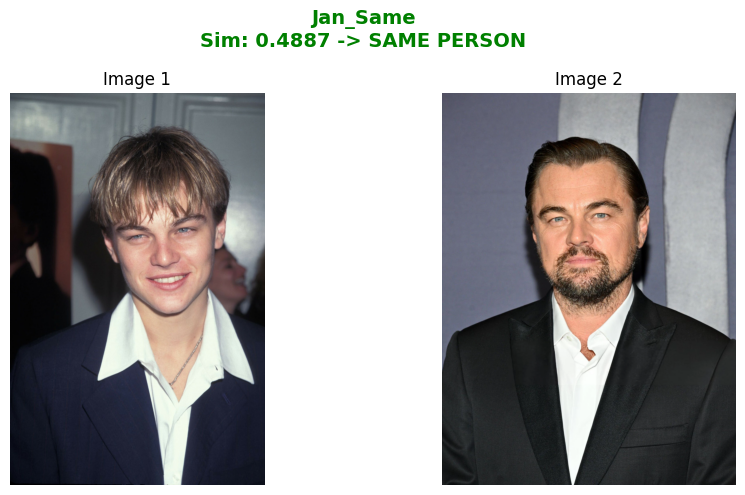

------------------------------------------------------------
 Image 1: jan1.jpg
 Image 2: jan2.jpg
 Similarity: 0.4887
 Verdict: [YES] SAME PERSON (Threshold: 0.35)



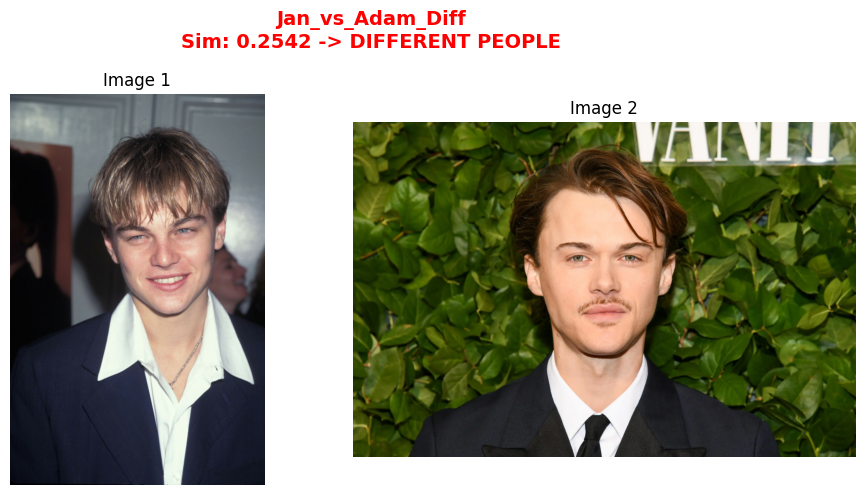

------------------------------------------------------------
 Image 1: jan1.jpg
 Image 2: adam1.jpg
 Similarity: 0.2542
 Verdict: [NO] DIFFERENT PEOPLE (Threshold: 0.35)



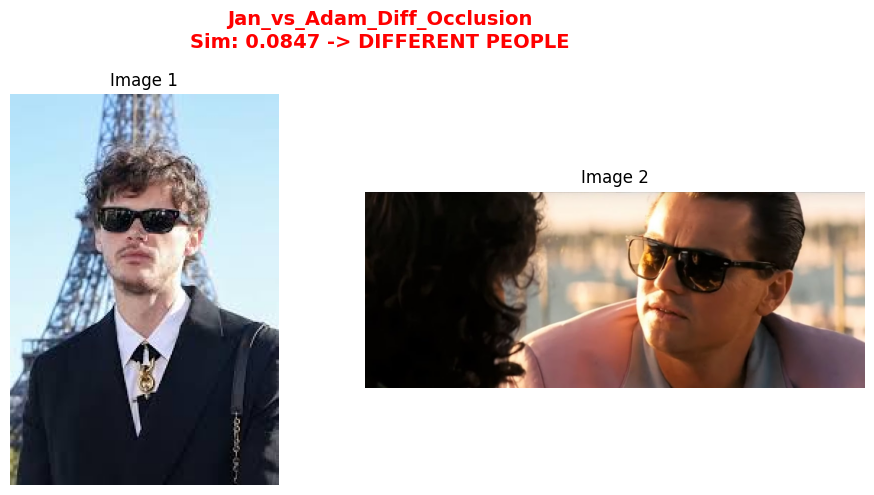

------------------------------------------------------------
 Image 1: adam_glasses.jpg
 Image 2: jan_glasses2.jpg
 Similarity: 0.0847
 Verdict: [NO] DIFFERENT PEOPLE (Threshold: 0.35)



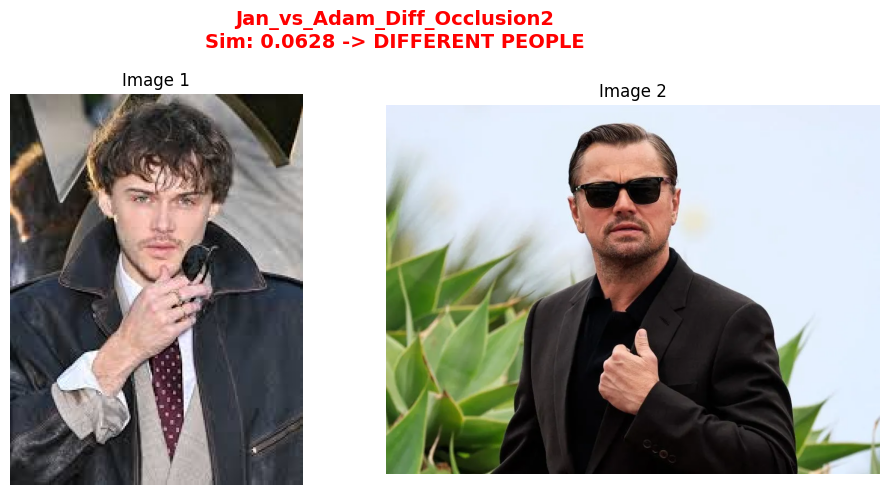

------------------------------------------------------------
 Image 1: adam2.jpg
 Image 2: jan_glasses.jpg
 Similarity: 0.0628
 Verdict: [NO] DIFFERENT PEOPLE (Threshold: 0.35)



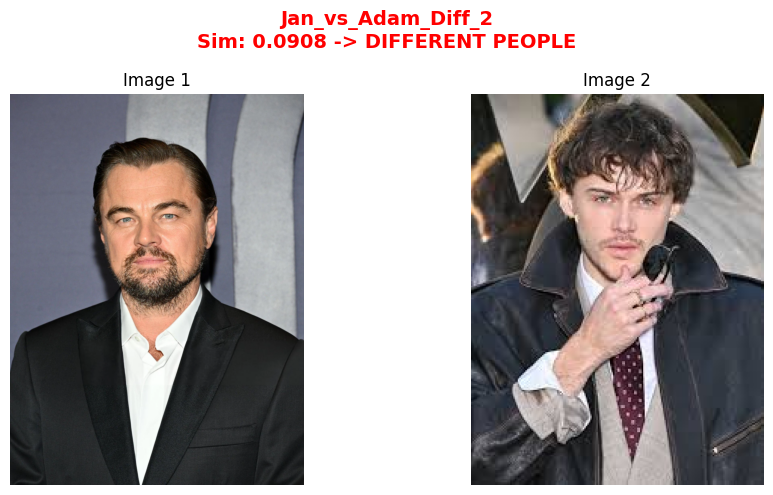

------------------------------------------------------------
 Image 1: jan2.jpg
 Image 2: adam2.jpg
 Similarity: 0.0908
 Verdict: [NO] DIFFERENT PEOPLE (Threshold: 0.35)



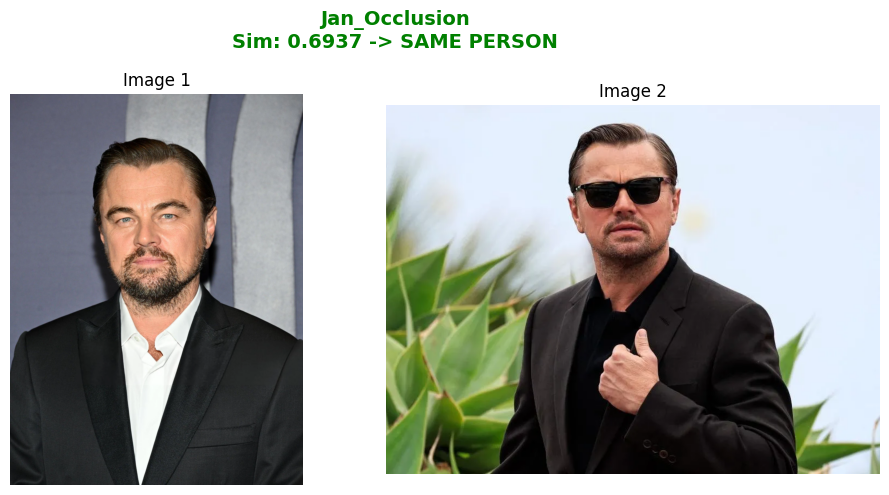

------------------------------------------------------------
 Image 1: jan2.jpg
 Image 2: jan_glasses.jpg
 Similarity: 0.6937
 Verdict: [YES] SAME PERSON (Threshold: 0.35)



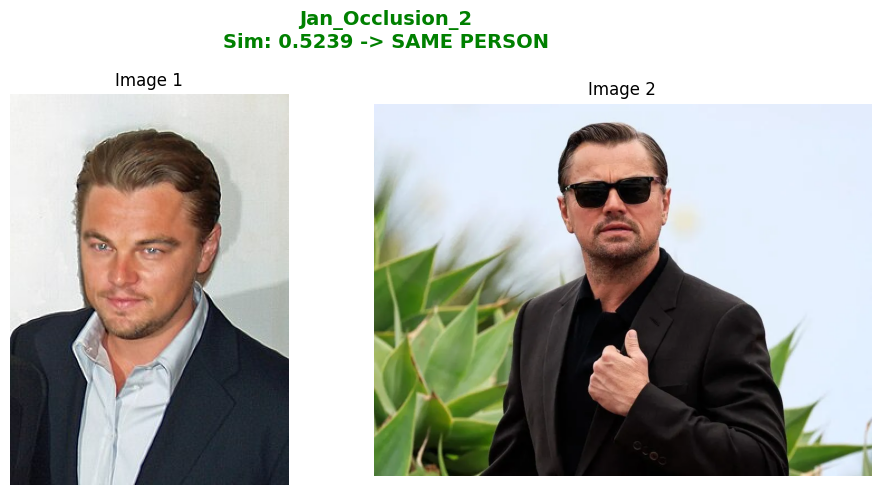

------------------------------------------------------------
 Image 1: jan3.jpg
 Image 2: jan_glasses.jpg
 Similarity: 0.5239
 Verdict: [YES] SAME PERSON (Threshold: 0.35)



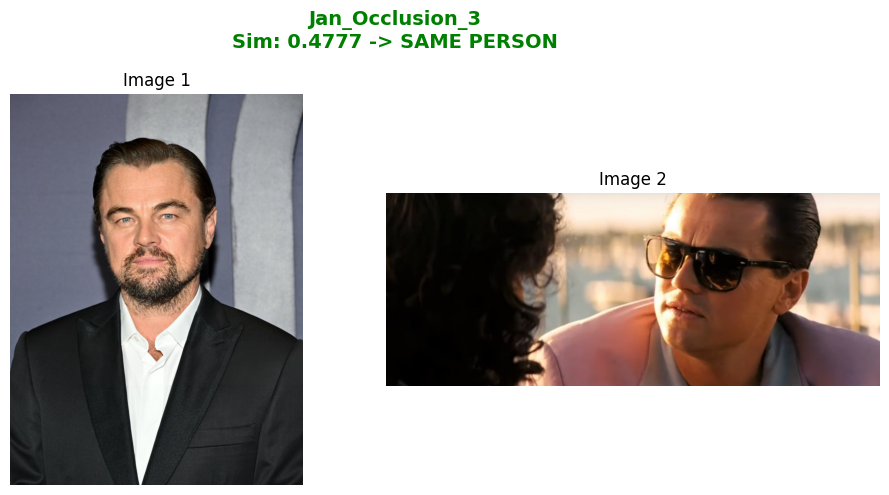

------------------------------------------------------------
 Image 1: jan2.jpg
 Image 2: jan_glasses2.jpg
 Similarity: 0.4777
 Verdict: [YES] SAME PERSON (Threshold: 0.35)



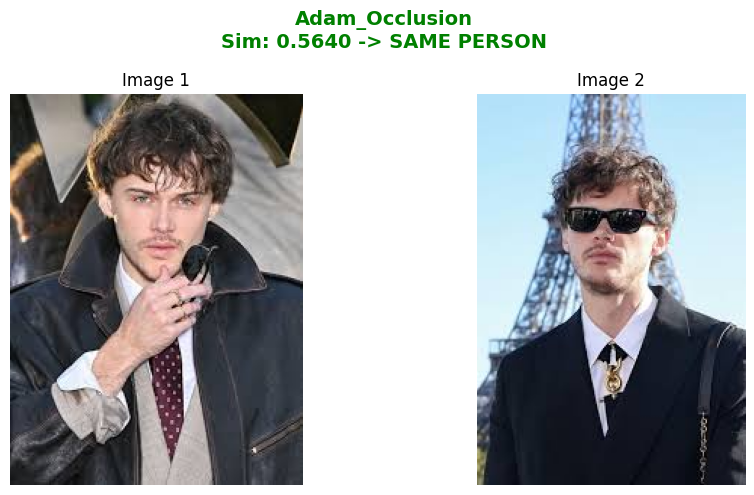

------------------------------------------------------------
 Image 1: adam2.jpg
 Image 2: adam_glasses.jpg
 Similarity: 0.5640
 Verdict: [YES] SAME PERSON (Threshold: 0.35)



In [20]:
if not os.path.exists("test_images"):
    os.makedirs("test_images")
    print("Created 'test_images' folder. Please add test images and update TEST_CASES in the code!")
else:
    main()